In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import random
import os
import gc
import time
import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

### 设置GPU显存按需分配

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


In [3]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
cpus = tf.config.experimental.list_physical_devices(device_type='CPU')
print(gpus, cpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
print(tf.__version__)

1.14.0


In [5]:
def reset_seed(seed=42):
    tf.keras.backend.clear_session()
    random.seed(seed)
    np.random.seed(seed)
    tf.set_random_seed(seed)

### 载入数据

In [6]:
data_train=pd.read_csv('F:/TensorFlow/xinjiang/traindata20250619.csv',header=0,encoding='utf_8')
data_train.info()
data_train.className.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Columns: 319 entries, className to Y
dtypes: float64(17), int64(301), object(1)
memory usage: 3.1+ MB


array(['芦苇草甸', '芦苇盐生草甸', '猪毛菜属荒漠', '新疆银穗草草原', '戈壁藜荒漠', '麻黄荒漠', '合头草荒漠',
       '短叶假木贼荒漠', '枇杷柴荒漠', '霸王荒漠', '膜果麻黄荒漠', '疏叶骆驼刺盐生草甸', '柽柳属灌丛',
       '柽柳属荒漠', '花花柴盐生草甸', '裸地', '驼绒藜荒漠', '冷蒿荒漠草原', '芨芨草草原', '旱蒿荒漠',
       '其他针茅草原', '镰芒针茅荒漠草原', '梭梭荒漠', '沙拐枣属荒漠', '紫花针茅草原',
       '新疆银穗草、穗状寒生羊茅荒漠草原', '小针茅荒漠草原', '盐生假木贼荒漠', '线叶嵩草草甸', '绢蒿属荒漠',
       '沙生针茅荒漠草原', '羊茅草原', '早熟禾草甸', '其它薹草草甸', '其它嵩草草甸', '草原苔草、杂类草草甸草原',
       '鸭茅草甸', '小蓬荒漠', '新疆薹草草原', '锦鸡儿属荒漠', '红砂荒漠', '胡杨荒漠', '芦苇荒漠',
       '骆驼刺荒漠'], dtype=object)

In [7]:
pd.set_option('display.max_rows', None)
print(data_train['className'].value_counts())

芦苇草甸                106
裸地                  100
芦苇盐生草甸               79
其他针茅草原               75
柽柳属荒漠                68
梭梭荒漠                 61
紫花针茅草原               51
绢蒿属荒漠                47
驼绒藜荒漠                41
猪毛菜属荒漠               36
疏叶骆驼刺盐生草甸            33
枇杷柴荒漠                29
其它薹草草甸               29
其它嵩草草甸               28
锦鸡儿属荒漠               27
盐生假木贼荒漠              26
旱蒿荒漠                 26
芨芨草草原                24
线叶嵩草草甸               22
花花柴盐生草甸              21
芦苇荒漠                 21
早熟禾草甸                20
麻黄荒漠                 20
羊茅草原                 19
镰芒针茅荒漠草原             19
膜果麻黄荒漠               19
戈壁藜荒漠                18
红砂荒漠                 17
冷蒿荒漠草原               17
胡杨荒漠                 17
沙拐枣属荒漠               16
合头草荒漠                16
短叶假木贼荒漠              14
小蓬荒漠                 14
草原苔草、杂类草草甸草原         13
骆驼刺荒漠                12
霸王荒漠                 12
小针茅荒漠草原              11
新疆银穗草草原              11
柽柳属灌丛                11
鸭茅草甸                 10
沙生针茅荒漠草原        

In [8]:
data_train.head()

,className,num,AET2020,AET2021,AET2101,AET2102,AET2103,AET2104,AET2105,AET2106,...,SR230821b07,SR230829b01,SR230829b02,SR230829b03,SR230829b04,SR230829b05,SR230829b06,SR230829b07,X,Y
0,芦苇草甸,0,39.333333,47.000000,0,32,71,50,66,58,...,1560,1576,2476,921,1406,2463,2369,1910,86.766240,42.038998
1,芦苇盐生草甸,1,47.083333,36.333333,0,9,15,18,82,114,...,3035,2671,3348,1485,2305,3488,3677,3190,84.183913,41.281745
2,芦苇草甸,0,46.500000,42.000000,0,30,36,22,98,127,...,2714,2272,2848,1371,1929,2958,3098,2817,84.276200,41.521080
3,芦苇草甸,0,18.166667,21.750000,0,1,79,8,48,30,...,2167,2044,2916,1104,1752,2971,2739,2031,86.637723,41.022153
4,芦苇盐生草甸,1,9.250000,15.166667,0,0,72,8,42,12,...,2333,1626,2597,836,1359,2653,2585,1955,87.885933,40.463570


In [9]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 类别数量

In [10]:
num_classes = data_train['num'].nunique()
print(num_classes)

44


### 切分数据集（已经提前切分的话不用此部分）

In [11]:
split_index = int(len(data_all)*0.8)
data_train = data_all.iloc[:split_index]

data_test = data_all.iloc[split_index:]
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 258 entries, 190 to 63
Columns: 319 entries, className to Y
dtypes: float64(17), int64(301), object(1)
memory usage: 645.0+ KB


In [12]:
#train_x = data_train.iloc[:,data_train.columns.str.contains("SR")]
#train_x = data_train.iloc[:,~ data_train.columns.str.contains('ClassName|num|SR')]
train_x = data_train.iloc[:,2:]
train_y = data_train.loc[:, ['num']] 

#test_x = data_test.iloc[:,data_train.columns.str.contains("SR")]
#test_x = data_test.iloc[:,~ data_test.columns.str.contains('ClassName|num|SR')]
test_x = data_test.iloc[:,2:]
test_y = data_test.loc[:, ['num']] 
train_x.head(), train_y.head()

(        AET2020     AET2021  AET2101  AET2102  AET2103  AET2104  AET2105  \
 974   80.833333   71.000000        0        0      235       38       43   
 50    30.250000   22.250000        0        7       41       12       74   
 967  161.833333  158.833333        0        0       14      701      119   
 7      7.583333   12.416667        0        0       59       13       39   
 695  219.833333  176.416667        0        0        0        0      840   
 
      AET2106  AET2107  AET2108  ...  SR230821b07  SR230829b01  SR230829b02  \
 974       48       92      128  ...         2726         1490         1894   
 50        52       26       27  ...         2473         1918         3288   
 967      446      115      229  ...         3550         2377         3076   
 7          9       15        3  ...         2649         2264         3096   
 695      403      510      311  ...         3296         1526         1885   
 
      SR230829b03  SR230829b04  SR230829b05  SR230829b06  SR

### 顺序编码转独热编码

In [13]:
train_y = tf.keras.utils.to_categorical(train_y)

In [14]:
pd.set_option('display.max_columns', None)
train_y

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], dtype=float32)

In [15]:
train_y.shape[1]

44

In [16]:
dim_num = train_x.shape[1]
print(dim_num)

317


### 定义损失函数为Focal Loss

In [17]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [18]:
reset_seed()
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(1024,input_dim=dim_num))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(64,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.Dropout(rate=0.2))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.01, patience=20, mode='auto')
model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
model.summary()


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 1024)              325632    
_________________________________________________________________
batch_normalization (BatchNo (None, 1024)              4096      
_________________________________________________________________
dense_1 (Dense)              (None, 512)               524800    
___________________________________

### 开始训练

In [19]:
e = 350
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=64,verbose=1,callbacks=[reduce_lr])#batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/350
1028/1028 [==============================] - 1s 803us/sample - loss: 1.4217 - acc: 0.1012
Epoch 2/350
1028/1028 [==============================] - 0s 108us/sample - loss: 0.7561 - acc: 0.2529
Epoch 3/350
1028/1028 [==============================] - 0s 121us/sample - loss: 0.4052 - acc: 0.2461
Epoch 4/350
1028/1028 [==============================] - 0s 119us/sample - loss: 0.2398 - acc: 0.2432
Epoch 5/350
1028/1028 [==============================] - 0s 114us/sample - loss: 0.1625 - acc: 0.2335
Epoch 6/350
1028/1028 [==============================] - 0s 117us/sample - loss: 0.1181 - acc: 0.2422
Epoch 7/350
1028/1028 [==============================] - 0s 115us/sample - loss: 0.0890 - acc: 0.2714
Epoch 8/350
1028/1028 [==============================] - 0s 113us/sample - loss: 0.0712 - acc: 0.2568
Epoch 9/350
1028/1028 [==============================] - 0s 112us/sample - loss: 0.0604 - 

1028/1028 [==============================] - 0s 112us/sample - loss: 0.0161 - acc: 0.4309
Epoch 78/350
1028/1028 [==============================] - 0s 114us/sample - loss: 0.0160 - acc: 0.4397
Epoch 79/350
1028/1028 [==============================] - 0s 107us/sample - loss: 0.0159 - acc: 0.4416
Epoch 80/350
1028/1028 [==============================] - 0s 124us/sample - loss: 0.0158 - acc: 0.4523
Epoch 81/350
1028/1028 [==============================] - 0s 114us/sample - loss: 0.0157 - acc: 0.4494
Epoch 82/350
1028/1028 [==============================] - 0s 127us/sample - loss: 0.0158 - acc: 0.4309
Epoch 83/350
1028/1028 [==============================] - 0s 113us/sample - loss: 0.0155 - acc: 0.4387
Epoch 84/350
1028/1028 [==============================] - 0s 117us/sample - loss: 0.0156 - acc: 0.4407
Epoch 85/350
1028/1028 [==============================] - 0s 121us/sample - loss: 0.0153 - acc: 0.4533
Epoch 86/350
1028/1028 [==============================] - 0s 116us/sample - loss: 0.01

1028/1028 [==============================] - 0s 119us/sample - loss: 0.0105 - acc: 0.6002
Epoch 157/350
1028/1028 [==============================] - 0s 118us/sample - loss: 0.0106 - acc: 0.6012
Epoch 158/350
1028/1028 [==============================] - 0s 120us/sample - loss: 0.0105 - acc: 0.6381
Epoch 159/350
1028/1028 [==============================] - 0s 122us/sample - loss: 0.0104 - acc: 0.6128
Epoch 160/350
1028/1028 [==============================] - 0s 122us/sample - loss: 0.0105 - acc: 0.6051
Epoch 161/350
1028/1028 [==============================] - 0s 127us/sample - loss: 0.0103 - acc: 0.6323
Epoch 162/350
1028/1028 [==============================] - 0s 118us/sample - loss: 0.0103 - acc: 0.6274
Epoch 163/350
1028/1028 [==============================] - 0s 110us/sample - loss: 0.0106 - acc: 0.6177
Epoch 164/350
1028/1028 [==============================] - 0s 133us/sample - loss: 0.0104 - acc: 0.5944
Epoch 165/350
1028/1028 [==============================] - 0s 148us/sample - l

1028/1028 [==============================] - 0s 117us/sample - loss: 0.0079 - acc: 0.7636
Epoch 235/350
1028/1028 [==============================] - 0s 110us/sample - loss: 0.0076 - acc: 0.7743
Epoch 236/350
1028/1028 [==============================] - 0s 112us/sample - loss: 0.0078 - acc: 0.7724
Epoch 237/350
1028/1028 [==============================] - 0s 123us/sample - loss: 0.0078 - acc: 0.7763
Epoch 238/350
1028/1028 [==============================] - 0s 115us/sample - loss: 0.0077 - acc: 0.7704
Epoch 239/350
1028/1028 [==============================] - 0s 124us/sample - loss: 0.0077 - acc: 0.7782
Epoch 240/350
1028/1028 [==============================] - 0s 115us/sample - loss: 0.0077 - acc: 0.7831
Epoch 241/350
1028/1028 [==============================] - 0s 148us/sample - loss: 0.0079 - acc: 0.7539
Epoch 242/350
1028/1028 [==============================] - 0s 131us/sample - loss: 0.0081 - acc: 0.7412
Epoch 243/350
1028/1028 [==============================] - 0s 110us/sample - l

1028/1028 [==============================] - 0s 131us/sample - loss: 0.0065 - acc: 0.8327
Epoch 313/350
1028/1028 [==============================] - 0s 161us/sample - loss: 0.0063 - acc: 0.8658
Epoch 314/350
1028/1028 [==============================] - 0s 116us/sample - loss: 0.0062 - acc: 0.8609
Epoch 315/350
1028/1028 [==============================] - 0s 112us/sample - loss: 0.0062 - acc: 0.8551
Epoch 316/350
1028/1028 [==============================] - 0s 114us/sample - loss: 0.0062 - acc: 0.8755
Epoch 317/350
1028/1028 [==============================] - 0s 108us/sample - loss: 0.0062 - acc: 0.8531
Epoch 318/350
1028/1028 [==============================] - 0s 125us/sample - loss: 0.0062 - acc: 0.8745
Epoch 319/350
1028/1028 [==============================] - 0s 126us/sample - loss: 0.0063 - acc: 0.8589
Epoch 320/350
1028/1028 [==============================] - 0s 129us/sample - loss: 0.0061 - acc: 0.8823
Epoch 321/350
1028/1028 [==============================] - 0s 117us/sample - l

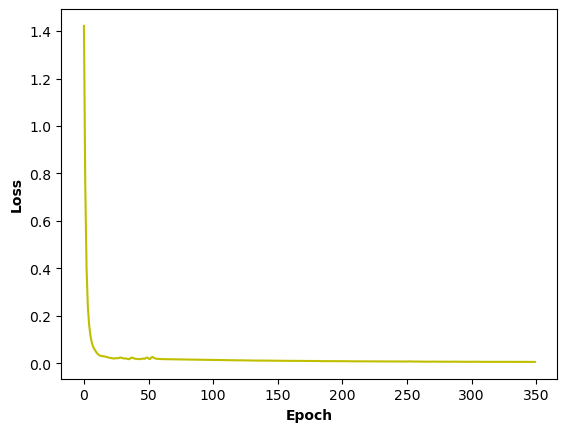

In [20]:
# 设置字体
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.plot(range(e),history.history.get('loss'),color =  'y')
#plt.savefig('XJloss20250526.png', bbox_inches='tight', pad_inches=0.0, dpi = 600)

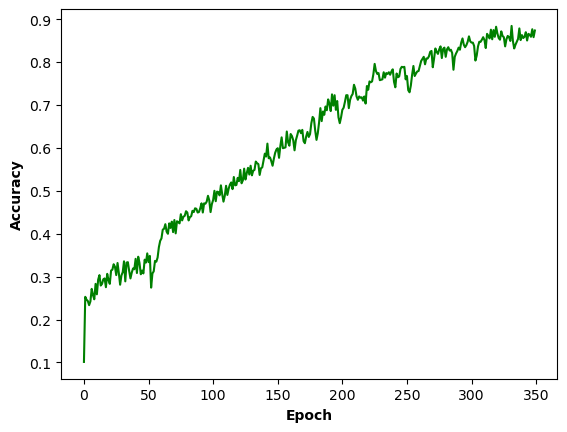

In [21]:
# 设置字体
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.plot(range(e),history.history.get('acc'),color =  'g')
#plt.savefig('XJacc20250526.png', bbox_inches='tight', pad_inches=0.0, dpi = 600)

### 计算准确率

In [22]:
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
# Accuracy
acc = accuracy_score(test_y, test_r)

# Precision, Recall, F1 (macro平均适用于多分类)
precision = precision_score(test_y, test_r, average='macro')
recall = recall_score(test_y, test_r, average='macro')
f1 = f1_score(test_y, test_r, average='macro')

# Confusion Matrix
cm = confusion_matrix(test_y, test_r)

print("Accuracy:", acc)
print("Precision (macro):", precision)
print("Recall (macro):", recall)
print("F1 Score (macro):", f1)
print("Confusion Matrix:\n", cm)

258/258 [==============================] - 0s 337us/sample
Accuracy: 0.3062015503875969
Precision (macro): 0.2539780926144562
Recall (macro): 0.2588586195678793
F1 Score (macro): 0.21851161364983615
Confusion Matrix:
 [[ 4  8  0 ...  0  1  0]
 [ 4 11  0 ...  0  0  0]
 [ 0  0  2 ...  0  0  0]
 ...
 [ 0  0  0 ...  1  1  0]
 [ 1  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]


D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### 各类别准确率

In [23]:
# 创建 num 到 className 的映射（取 data_train 中唯一的映射关系）
num_to_name = data_train.drop_duplicates(subset='num').set_index('num')['className'].to_dict()

# 每类准确率 = 对角线元素 / 该类总数（行和）
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

# 每类样本数量（即该类在混淆矩阵中的行和）
per_class_count = cm.sum(axis=1)

# 输出每个类别的名称、准确率和样本数量
print("每个类别的准确率和样本数量：")
for i in sorted(num_to_name.keys()):
    name = num_to_name[i]
    acc = per_class_accuracy[i]
    count = per_class_count[i]
    print(f"{name}: acc: {acc:.2%}，count: {count}")

每个类别的准确率和样本数量：
芦苇草甸: acc: 20.00%，count: 20
芦苇盐生草甸: acc: 64.71%，count: 17
猪毛菜属荒漠: acc: 18.18%，count: 11
新疆银穗草草原: acc: 0.00%，count: 1
戈壁藜荒漠: acc: 25.00%，count: 4
麻黄荒漠: acc: 0.00%，count: 4
合头草荒漠: acc: 33.33%，count: 3
短叶假木贼荒漠: acc: 0.00%，count: 4
枇杷柴荒漠: acc: 0.00%，count: 6
霸王荒漠: acc: 16.67%，count: 6
膜果麻黄荒漠: acc: 100.00%，count: 2
疏叶骆驼刺盐生草甸: acc: 0.00%，count: 5
柽柳属灌丛: acc: 50.00%，count: 2
柽柳属荒漠: acc: 41.67%，count: 12
花花柴盐生草甸: acc: 33.33%，count: 6
裸地: acc: 78.95%，count: 19
驼绒藜荒漠: acc: 37.50%，count: 8
冷蒿荒漠草原: acc: 20.00%，count: 5
芨芨草草原: acc: 14.29%，count: 7
旱蒿荒漠: acc: 0.00%，count: 3
其他针茅草原: acc: 12.50%，count: 16
镰芒针茅荒漠草原: acc: 33.33%，count: 3
梭梭荒漠: acc: 50.00%，count: 10
沙拐枣属荒漠: acc: 0.00%，count: 3
紫花针茅草原: acc: 41.67%，count: 12
新疆银穗草、穗状寒生羊茅荒漠草原: acc: 100.00%，count: 1
小针茅荒漠草原: acc: 0.00%，count: 2
盐生假木贼荒漠: acc: 66.67%，count: 3
线叶嵩草草甸: acc: 0.00%，count: 2
绢蒿属荒漠: acc: 33.33%，count: 12
沙生针茅荒漠草原: acc: 0.00%，count: 2
羊茅草原: acc: 0.00%，count: 4
早熟禾草甸: acc: 0.00%，count: 3
其它薹草草甸: acc: 40.00%，count: 5
其它嵩

In [24]:
# 转成 DataFrame，方便处理
df_test = pd.DataFrame({
    'num': test_y.iloc[:, 0].values,    # 从 DataFrame 中取出标签列
    'pred': test_r.flatten()            # 如果 test_r 是 numpy array
})

# 读入 num 到 植被型 的映射表
map_df = pd.read_csv('F:/TensorFlow/xinjiang/新疆20240718所有类别.csv', header=0, encoding='utf_8')  # 包含列：num，植被型

# 添加真实大类列
df_test = df_test.merge(map_df[['num', '植被型']], on='num', how='left')
df_test = df_test.rename(columns={'植被型': '真实植被型'})

# 添加预测大类列（通过预测的 pred 映射）
df_test = df_test.merge(map_df[['num', '植被型']], left_on='pred', right_on='num', how='left')
df_test = df_test.rename(columns={'植被型': '预测植被型'})
df_test = df_test.drop(columns=['num_y'])  # 删除多余列
df_test = df_test.rename(columns={'num_x': 'num'})  # 恢复 num

# 🧼【修正部分】：去掉包含 NaN 的行并转换为字符串
df_eval = df_test.dropna(subset=['真实植被型', '预测植被型']).copy()
y_true_big = df_eval['真实植被型'].astype(str)
y_pred_big = df_eval['预测植被型'].astype(str)

# ✅ 计算评估指标
acc = accuracy_score(y_true_big, y_pred_big)
precision = precision_score(y_true_big, y_pred_big, average='macro')
recall = recall_score(y_true_big, y_pred_big, average='macro')
f1 = f1_score(y_true_big, y_pred_big, average='macro')

# ✅ 混淆矩阵（确保标签一致顺序）
labels = sorted(y_true_big.unique())
conf_mat = confusion_matrix(y_true_big, y_pred_big, labels=labels)

# ✅ 输出
print(f"【大类层级总体指标】")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

【大类层级总体指标】
Accuracy : 0.4419
Precision: 0.3344
Recall   : 0.2997
F1 Score : 0.3013


In [25]:
print(f"\n被排除的样本数（含NaN大类）: {len(df_test) - len(df_eval)}")


被排除的样本数（含NaN大类）: 0


In [26]:
# 统计每个植被型的测试数量和准确数
summary = (
    df_test
    .groupby('真实植被型')
    .agg(
        测试数量=('真实植被型', 'count'),
        正确数量=('预测植被型', lambda x: (x == df_test.loc[x.index, '真实植被型']).sum())
    )
    .assign(准确率=lambda df: df['正确数量'] / df['测试数量'])
    .sort_values('测试数量', ascending=False)
)

# 输出
print(summary.reset_index().to_string(index=False))

   真实植被型  测试数量  正确数量      准确率
半灌木与草本荒漠    87    60 0.689655
   半灌木草甸    37    20 0.540541
  丛生草类草原    26     6 0.230769
  根茎草类草甸    26     7 0.269231
   半灌木草原    24     9 0.375000
半乔木与灌木荒漠    18     3 0.166667
   杂类草草甸    16     2 0.125000
      裸地    10     5 0.500000
   杂类草草原     5     1 0.200000
  落叶阔叶灌丛     5     1 0.200000
  丛生草类草甸     4     0 0.000000
